In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Load image (grayscale) ────────────────────────────────────────────────────
img = cv2.imread('input.jpg', cv2.IMREAD_GRAYSCALE)
assert img is not None, "Place 'input.jpg' in the same folder as this notebook."
img = img.astype(np.float32)

# ── Helper: compute shifted magnitude spectrum (log scale) ───────────────────
def fft_spectrum(image):
    F = np.fft.fft2(image)
    Fshift = np.fft.fftshift(F)
    magnitude = np.log1p(np.abs(Fshift))
    return F, Fshift, magnitude

# ── Helper: build circular mask centred at image centre ──────────────────────
def circular_mask(shape, radius, inside_value=1, outside_value=0):
    rows, cols = shape
    cy, cx = rows // 2, cols // 2
    Y, X = np.ogrid[:rows, :cols]
    dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
    mask = np.where(dist <= radius, inside_value, outside_value).astype(np.float32)
    return mask

print(f"Image loaded: {img.shape[1]}×{img.shape[0]} px")

Image loaded: 512×512 px


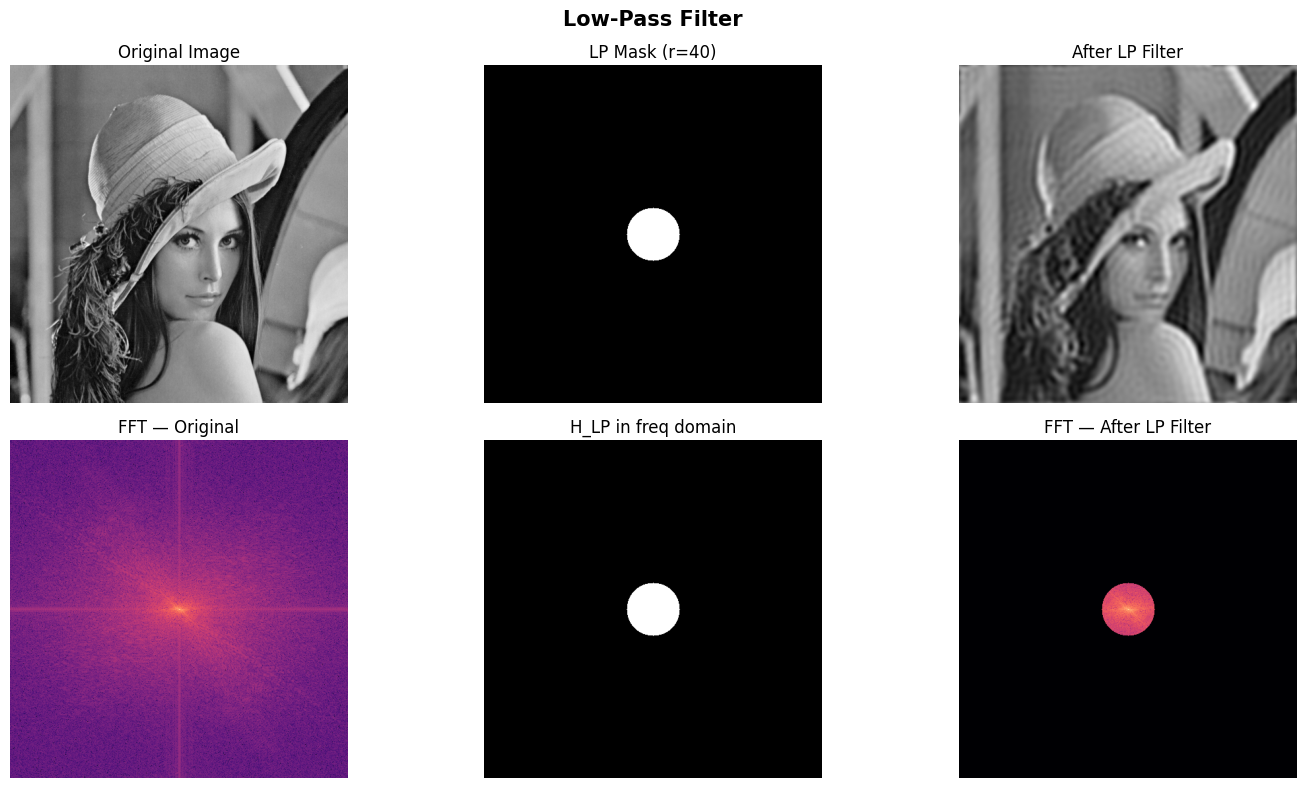

Low-pass result saved.


In [3]:
# ── Low-Pass Filter in Frequency Domain ──────────────────────────────────────
# Math: multiply FFT(image) by H_LP where H_LP = 1 inside circle, 0 outside
# Then IFFT gives the smoothed (blurred) image.
# Removes high-frequency (edge/noise) components.

cutoff_lp = 40  # radius in pixels — tweak as needed

F_orig, Fshift_orig, mag_orig = fft_spectrum(img)

H_lp = circular_mask(img.shape, cutoff_lp, inside_value=1, outside_value=0)
Fshift_lp = Fshift_orig * H_lp
F_lp = np.fft.ifftshift(Fshift_lp)
img_lp = np.real(np.fft.ifft2(F_lp))
img_lp = np.clip(img_lp, 0, 255)

mag_lp = np.log1p(np.abs(Fshift_lp))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Low-Pass Filter', fontsize=15, fontweight='bold')

axes[0,0].imshow(img, cmap='gray'); axes[0,0].set_title('Original Image')
axes[0,1].imshow(H_lp, cmap='gray'); axes[0,1].set_title(f'LP Mask (r={cutoff_lp})')
axes[0,2].imshow(img_lp, cmap='gray'); axes[0,2].set_title('After LP Filter')

axes[1,0].imshow(mag_orig, cmap='magma'); axes[1,0].set_title('FFT — Original')
axes[1,1].imshow(H_lp, cmap='gray'); axes[1,1].set_title('H_LP in freq domain')
axes[1,2].imshow(mag_lp, cmap='magma'); axes[1,2].set_title('FFT — After LP Filter')

for ax in axes.flat: ax.axis('off')
plt.tight_layout()
plt.savefig('lp_result.png', dpi=120)
plt.show()
print("Low-pass result saved.")

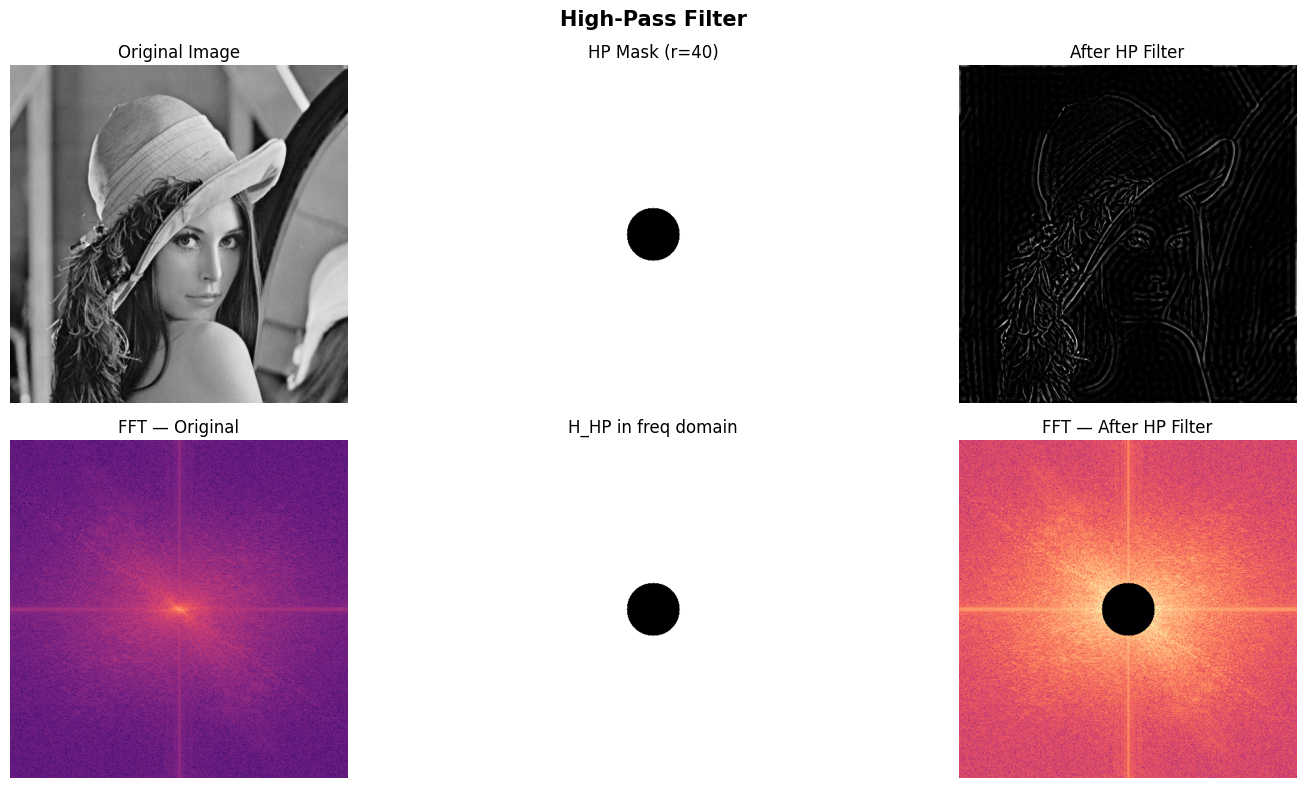

High-pass result saved.


In [4]:
# ── High-Pass Filter in Frequency Domain ─────────────────────────────────────
# Math: H_HP = 1 − H_LP  (complement of LP mask)
# Keeps high-frequency components (edges), removes smooth regions.

cutoff_hp = 40  # same cutoff for fair comparison

H_hp = 1.0 - circular_mask(img.shape, cutoff_hp)
Fshift_hp = Fshift_orig * H_hp
F_hp = np.fft.ifftshift(Fshift_hp)
img_hp = np.real(np.fft.ifft2(F_hp))
img_hp = np.clip(img_hp, 0, 255)

mag_hp = np.log1p(np.abs(Fshift_hp))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('High-Pass Filter', fontsize=15, fontweight='bold')

axes[0,0].imshow(img, cmap='gray'); axes[0,0].set_title('Original Image')
axes[0,1].imshow(H_hp, cmap='gray'); axes[0,1].set_title(f'HP Mask (r={cutoff_hp})')
axes[0,2].imshow(img_hp, cmap='gray'); axes[0,2].set_title('After HP Filter')

axes[1,0].imshow(mag_orig, cmap='magma'); axes[1,0].set_title('FFT — Original')
axes[1,1].imshow(H_hp, cmap='gray'); axes[1,1].set_title('H_HP in freq domain')
axes[1,2].imshow(mag_hp, cmap='magma'); axes[1,2].set_title('FFT — After HP Filter')

for ax in axes.flat: ax.axis('off')
plt.tight_layout()
plt.savefig('hp_result.png', dpi=120)
plt.show()
print("High-pass result saved.")

Max pixel difference (spatial vs freq): 75.8217
Mean pixel difference: 2.588505


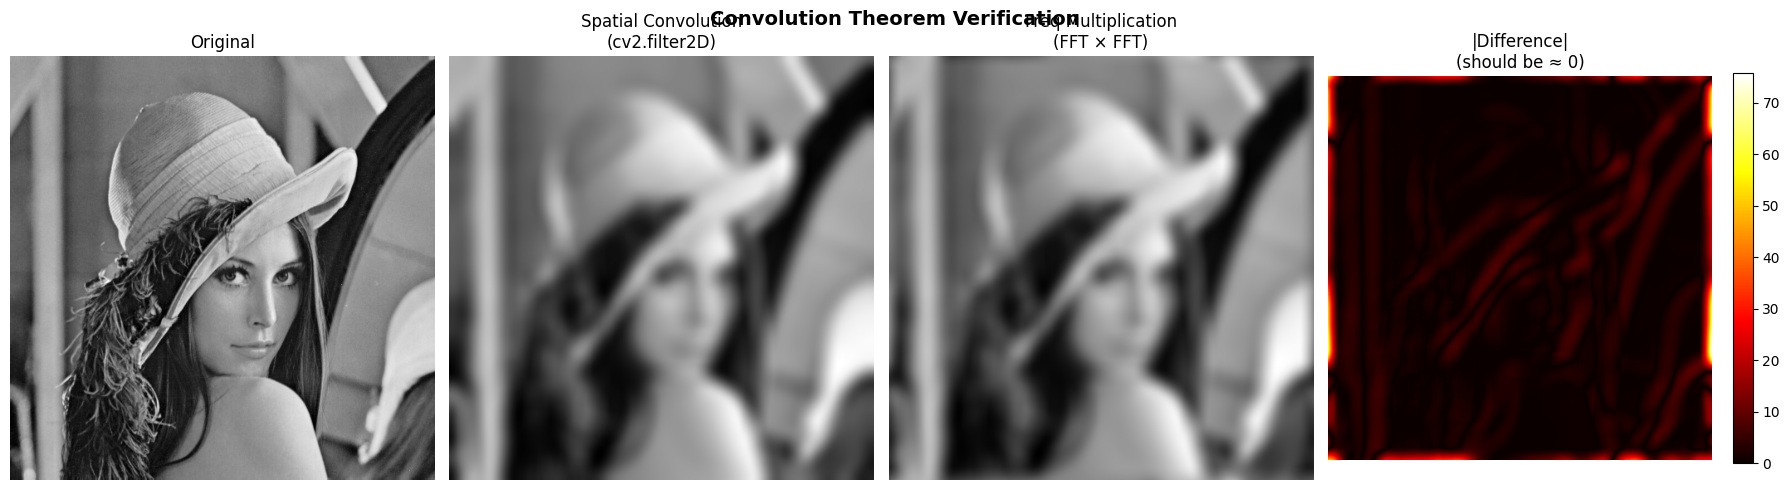

In [5]:
# ── Verify: Convolution in spatial = Multiplication in frequency ──────────────
# Math: F{f * h} = F{f} · F{h}   (convolution theorem)
# We use a Gaussian kernel as our LP filter kernel.
# Method A: convolve in spatial domain using cv2.filter2D
# Method B: multiply FFTs, then IFFT
# Both should yield the same result (difference ≈ 0).

ksize = 31
sigma = 10.0
gauss_kernel_1d = cv2.getGaussianKernel(ksize, sigma)
gauss_kernel_2d = gauss_kernel_1d @ gauss_kernel_1d.T  # outer product → 2D kernel

# Method A: spatial convolution
img_conv_spatial = cv2.filter2D(img, -1, gauss_kernel_2d)

# Method B: frequency multiplication
rows, cols = img.shape
# Pad kernel to image size
kernel_padded = np.zeros((rows, cols), dtype=np.float32)
ky, kx = gauss_kernel_2d.shape
kernel_padded[:ky, :kx] = gauss_kernel_2d
# Shift kernel centre to match FFT convention
kernel_padded = np.roll(kernel_padded, -ky//2, axis=0)
kernel_padded = np.roll(kernel_padded, -kx//2, axis=1)

F_img = np.fft.fft2(img)
F_ker = np.fft.fft2(kernel_padded)
img_conv_freq = np.real(np.fft.ifft2(F_img * F_ker))
img_conv_freq = np.clip(img_conv_freq, 0, 255)

diff = np.abs(img_conv_spatial.astype(np.float32) - img_conv_freq)
print(f"Max pixel difference (spatial vs freq): {diff.max():.4f}")
print(f"Mean pixel difference: {diff.mean():.6f}")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Convolution Theorem Verification', fontsize=14, fontweight='bold')

axes[0].imshow(img, cmap='gray'); axes[0].set_title('Original')
axes[1].imshow(img_conv_spatial, cmap='gray'); axes[1].set_title('Spatial Convolution\n(cv2.filter2D)')
axes[2].imshow(img_conv_freq, cmap='gray'); axes[2].set_title('Freq Multiplication\n(FFT × FFT)')
im = axes[3].imshow(diff, cmap='hot'); axes[3].set_title('|Difference|\n(should be ≈ 0)')
plt.colorbar(im, ax=axes[3], fraction=0.046)

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig('convolution_theorem.png', dpi=120)
plt.show()

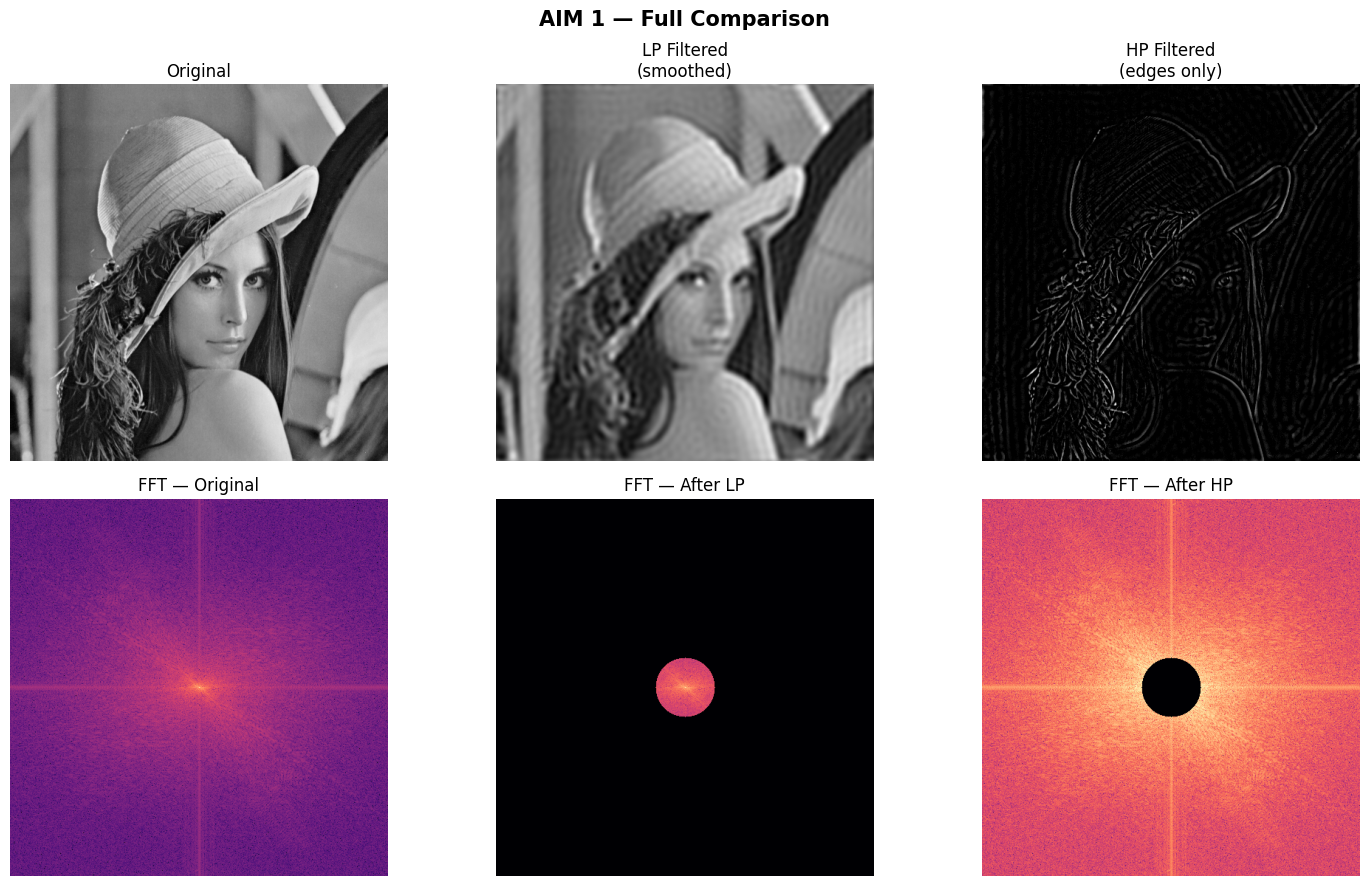

PSNR (LP vs Original): 27.00 dB
PSNR (HP vs Original): 5.43 dB
AIM 1 complete ✓


In [6]:
# ── Final Comparison: Original vs LP vs HP ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('AIM 1 — Full Comparison', fontsize=15, fontweight='bold')

titles_img = ['Original', 'LP Filtered\n(smoothed)', 'HP Filtered\n(edges only)']
images_img = [img, img_lp, img_hp]
titles_fft = ['FFT — Original', 'FFT — After LP', 'FFT — After HP']
ffts       = [mag_orig, mag_lp, mag_hp]

for i in range(3):
    axes[0, i].imshow(images_img[i], cmap='gray')
    axes[0, i].set_title(titles_img[i], fontsize=12)
    axes[1, i].imshow(ffts[i], cmap='magma')
    axes[1, i].set_title(titles_fft[i], fontsize=12)

for ax in axes.flat: ax.axis('off')
plt.tight_layout()
plt.savefig('aim1_comparison.png', dpi=120)
plt.show()

# Print PSNR relative to original
def psnr(a, b):
    mse = np.mean((a - b)**2)
    return 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')

print(f"PSNR (LP vs Original): {psnr(img, img_lp):.2f} dB")
print(f"PSNR (HP vs Original): {psnr(img, img_hp):.2f} dB")
print("AIM 1 complete ✓")